# 1. Linear Regression

### 가상의 데이터로 예측하기

In [1]:
from sklearn.datasets import make_regression

-  Scikit-Learn의 datasets 서브패키지는 회귀분석용 가상 데이터를 생성하는 명령어인 make_regression()을 제공한다. make_regression()으로 만들어진 데이터는 종속 변수 y의 값이 독립변수 x 벡터의 선형 조합인 선형관계를 가진다.

In [12]:
# 가상의 데이터 생성
data = make_regression(n_samples = 1000, n_features = 1, bias = 1000, noise = 50)
# 1000개의 데이터, 1개의 특성 가진 데이터 셋을 생성합니다.

#X_1 -> data[0] / y_1 -> data[1]

In [13]:
print('input data :\n{}, \n\n output data :\n{}'.format(data[0][-10:], data[1][-10:]))

input data :
[[ 0.72393312]
 [-0.64497487]
 [ 1.20881759]
 [ 1.82147212]
 [-2.46451428]
 [-0.69744454]
 [ 0.2396416 ]
 [-0.17271905]
 [ 0.70466347]
 [-1.65056955]], 

 output data :
[1159.39894369  981.99533908  949.8452763  1060.79034956  874.03491419
  997.55192414 1056.58426962  955.51389607 1103.23846964  756.39251078]


- n_samples : 기본값은 100, 표본 데이터의 갯수, 정수
- n_features : 기본값은 100, 독립변수의 수(차원), 정수
- n_target : 기본값은 1, 종속변수의 수, 정수
- bias = 기본값은 0.0, y절편, 실수
- nosie = 기본값은 0.0, 분포

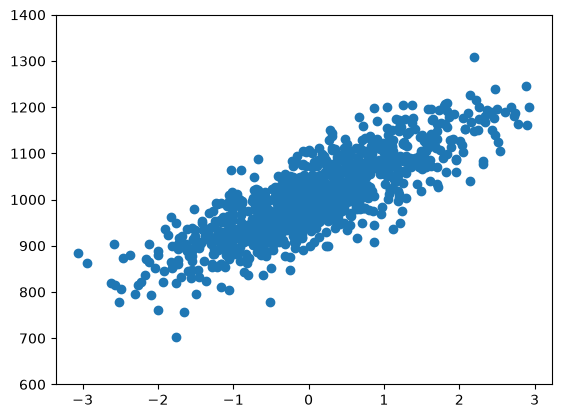

In [14]:
# 위에서 생성한 가상 데이터 셋을 그래프위에 그려 보았습니다.
from matplotlib import pyplot as plt
%matplotlib inline
plt.scatter(data[0], data[1])
plt.ylim(600, 1400)
plt.show()

#### 선형 모델을 만들어 보자.

In [15]:
from sklearn.model_selection import train_test_split
# train_test_split은 데이터를 학습용 데이터와 검증용 데이터로 분리시켜줍니다.

X_train, X_test, y_train, y_test = train_test_split(data[0], data[1], test_size = 0.2, shuffle = True)

# 생성한 가상의 데이터를 훈련용 데이터와 검증 데이터로 나눠주는 과정입니다.

- train_test_split(data, data2, test_size, train_size, shuffle, random_state)  
  data: 독립변수 데이터  
  data2: 종속변수 데이터 (data 인수에 종속변수가 포함되어 있다면 생략해도 된다.)  
  test_size: 검증용 데이터의 개수. 1이하의 실수로 표현하면 비율을 나타낸다. (기본값은 0.25)  
  train_size : 학습용 데이터의 개수. 1이하의 실수로 표현하면 비율을 나타낸다.(test_size와 train_size 중 하나만 사용해도 된다.)  
  shuffle: 데이터를 섞어준다. (기본값은 True)  
  random_state: 난수를 생성해준다.

In [16]:
# 선형회귀(Linear Regression)

from sklearn.linear_model import LinearRegression
# LinearRegression을 import 합니다.

hypothesis = LinearRegression()
# import한 LinearRegression을 model이라는 변수에 대입한다.
# 굳이 별도의 변수에 넣어주지 않고 LinearRegression() 으로 사용해도 무방합니다. 여기서는 설명을 위해 변수에 대입하였습니다.

# 단일피쳐 선형회귀 모델의 가설함수는?
# y = wx + b
# 다변량
# y = w1x1 + w2x2 + ... b

#### 생성한 모델을 학습시켜보자.

In [17]:
model_linear = hypothesis.fit(X_train, y_train)
# fit()은 모델을 학습시키는 명령입니다.

# fit 에서 일어나는 일에는 어떤 것들이 있을까?
# 1. weight 초기화
# 2. cost 계산
# 3. Cost 가장 낮을 때로 가중치 업데이트 (반복)
# 3-1. cost 함수에 대해 기울기를 구한다 -> w에 대해서 기울기를 구한다. -> 편미분
# 3-2. 기울기에 반대방향으로 가중치를 업데이트해준다.

#### 생성한 모델의 weight(가중치, 계수)와 bias를 출력해보자.

In [18]:
model_linear.coef_
# coef_ 속성은 각 입력 특성에 하나씩 대응되는 Numpy 배열입니다.
# 우리가 생성한 데이터에는 입력 특성이 하나이므로 하나만 출력됩니다.
# coef_ 는 weight값을 보여줍니다.

array([70.42178118])

In [19]:
model_linear.intercept_
# intercept_ 속성은 항상 실수 값 하나입니다.
# intercept_ 는 bias(y 절편)값을 보여줍니다.

np.float64(999.9735869242948)

#### 우리가 생성한 모델을 검증 해보자.

- score()로 모델을 검증할 수 있다.

In [20]:
print("train data score : {:.2f}".format(model_linear.score(X_train, y_train)))
print("test data score : {:.2f}".format(model_linear.score(X_test, y_test)))

train data score : 0.69
test data score : 0.65


In [22]:
X_train.max()

np.float64(2.9278466653760553)

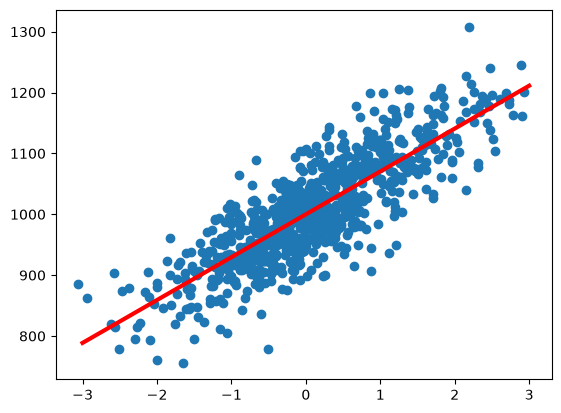

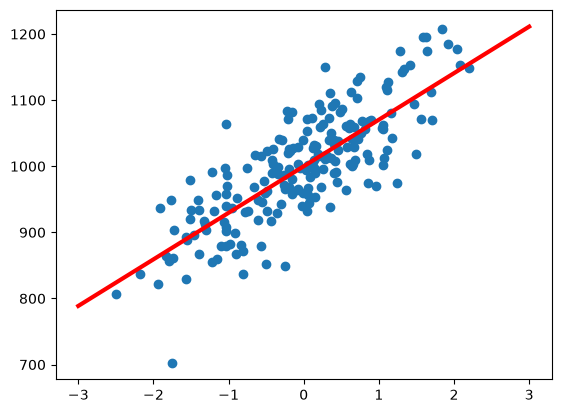

In [ ]:
# Trainset data 와 함께, Hypothesis (직선) 시각화해보기
# Testset data 와 함께, Hypothesis (직선) 시각화해보기

# y = wx + b
import numpy as np

plot_x = np.linspace(-3, 3, 2)
plot_y = model_linear.predict(plot_x.reshape(-1, 1))

plt.plot(plot_x, plot_y, color='red', lw=3)
plt.scatter(X_train, y_train)
plt.show()

plt.plot(plot_x, plot_y, color='red', lw=3)
plt.scatter(X_test, y_test)
plt.show()

In [29]:
from sklearn.metrics import mean_squared_error, r2_score
# 회귀 평가 지표인 mean squared error, R2 score를 불러옵니다.

y_predict = model_linear.predict(X_test)
# predcit() 명령어를 사용하여 y값을 예측합니다.

In [30]:
mse = mean_squared_error(y_test, y_predict)
# 실제 값과 예측값을 이용하여 mean squared error를 측정합니다.
mse

2520.1886060432407

In [ ]:
import numpy as np
rmse = np.sqrt(mse)
# root mean squared error를 측정할 수 있습니다.
# sqrt는 루트를 씌워주는 명령어입니다.
rmse

50.2014801180527

In [33]:
print('MSE : {:.3f}, RMSE : {:.3f}'.format(mse, rmse))

MSE : 2520.189, RMSE : 50.201


In [34]:
print('test data score : {:.2f}'.format(r2_score(y_test, y_predict)))
# 실제값과 직접 만들어본 예측값을 이용하여 모델의 성능을 측정할 수 있습니다.

test data score : 0.65


In [35]:
1 - (mse / np.var(y_test))

np.float64(0.6501326620460715)

Quiz.
1. 회귀에서 r2 score를 사용하는 이유는 무엇일까?
2. r2_score는 계산하는 식이 어떻게 될까?

In [ ]:
# 데이터셋 자체의 분산에 대해서, 모델이 얼마만큼의 분산을 설명할 수 있는지를 표현하기 위해 사용한다.
# 1 - (MSE / SS)

- score(X_test, y_test)를 실행하게 되면 내부함수에서 X_test를 이용하여 예측값을 생성합니다. 그 후 생성된 예측값과 y_test(실제값)을 이용하여 성능을 검증해줍니다.
- 모델의 성능만을 측정할때는 위의 번거로운 과정없이 score함수만을 활용하면 됩니다.

#### Linear Regression with Multi-Variable

앞에서는 1개의 특성(feature)을 가진 데이터 셋으로 선형회귀를 해보았다. 지금부터는 여러개의 특성을 가진 데이터 셋으로 션형회귀를 해보자.

In [36]:
X_multi, y_multi = make_regression(n_samples = 1000, n_features = 100, bias = 10, noise = 50)

print('input data : \n{}, \n\n output data : \n{}'.format(X_multi[:1], y_multi[:1]))

input data : 
[[ 1.74562296 -0.10843158  0.48172297  1.34861774  0.40925511  0.1183776
  -0.05575001  0.00929414  1.61305278  0.82382528  0.69100268  1.3684856
  -0.34541455  0.68053075 -0.02650378 -0.66354451 -2.36805644  0.79458802
   1.97999566 -1.226061    1.2366373  -0.86820911  0.01689343 -0.04149773
  -1.67540151 -0.54266663  0.51963033  1.64932234 -0.20331668 -0.39871272
   1.80008913  0.27581592  0.243421    0.20659904 -0.77626359 -0.66283371
   0.87077189  0.31003391  0.3901943  -0.24584613 -1.23418257 -0.7809077
  -2.05155471  1.05868264  0.86093513 -1.1472503   1.84790565 -1.26090105
   0.43850283  0.2982155  -0.22808907 -0.03260212  0.5476464   0.86726603
  -0.73162094 -0.93082711 -0.90142001 -0.0567793   0.48818948 -0.80054338
  -0.46536849  0.53280267  1.00520355 -0.21207588  0.85099317 -0.22227296
  -0.3784249  -0.51222305 -0.01336853  0.75522418 -0.5621569  -0.79484789
  -0.55619211 -0.08679385 -0.26066597  0.57955492 -2.05692041 -0.0341682
  -1.10620403  0.58004508 -0

여기서는 input data를 살펴보도록 하자.
1개의 input data에 100개의 각각 다른 값들이 들어있다. 그 이유는 n_features = 100, 즉 100개의 특성을 가지고 있는 데이터이다.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size = 0.3, shuffle = True)
# 생성한 가상의 데이터를 학습용과 검증용으로 나눠줍니다.

In [38]:
hypothesis_multi = LinearRegression()

# 가설함수는 어떻게 될까?
# y = w1x1+ w2x2+ ... + w100x100 + w0

In [39]:
model_linear_multi = hypothesis_multi.fit(X_train, y_train)
# 모델을 학습시킵니다.

In [40]:
print('weight : \n{}\n\n'.format(model_linear_multi.coef_))
print('bias : \n{}'.format(model_linear_multi.intercept_))

weight : 
[ 1.51708653e+00  1.85182677e+00  2.08080390e+00 -8.52673142e-02
  2.42965804e+00 -1.24700758e+00 -4.19053591e+00 -2.84131781e+00
 -1.34400105e+00 -1.77407423e+00  1.32546782e+00 -3.07195509e+00
 -2.68933271e-01 -1.46914492e+00 -5.00056141e-01 -4.65613123e+00
 -1.47111199e+00  2.25440732e+00  4.79054567e-01  5.41111594e-01
  4.11811785e+01  5.90585151e-01  5.96695782e-01 -8.69171749e-01
 -1.44646996e+00  1.85587540e-01 -1.45850750e+00  1.40890258e+00
  4.94585441e-01 -1.13263335e+00 -3.26103024e+00 -1.36428122e+00
  1.93917765e+00  4.27548609e-01  9.35219437e-01  2.85188884e+00
 -6.14838123e+00  1.94609909e+01 -9.29333125e-01  1.98014446e+00
 -2.16648028e+00  5.13639998e-01  1.77689556e-01  1.18983704e-02
  6.92590720e+01  4.41394438e-01 -2.40777148e+00  7.32450034e-01
 -3.23778097e+00  3.71542924e+00  4.51046754e-01  1.44591142e+01
  2.89436686e-01 -8.35818714e-01 -1.64701319e+00 -4.50440947e+00
  1.10995121e-01 -1.11921743e+00  1.79228656e+00  4.87534716e-01
  1.34694151e+0

In [41]:
print('학습 데이터 점수 : {:.2f}'.format(model_linear_multi.score(X_train, y_train)))
print('검증 데이터 점수 : {:.2f}'.format(model_linear_multi.score(X_test, y_test)))

학습 데이터 점수 : 0.91
검증 데이터 점수 : 0.84


noise = 100

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_2,y_2 = make_regression(n_samples = 1000, n_features = 1, bias = 10, noise = 200)

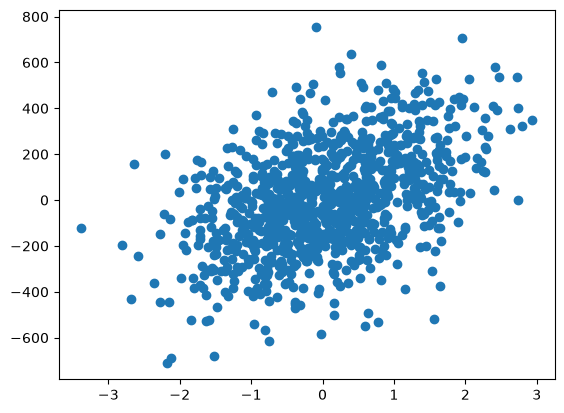

In [43]:
from matplotlib import pyplot as plt
plt.scatter(X_2, y_2)
plt.show()

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X_2, y_2, test_size = 0.2,
                                                    shuffle = True)
hypothesis_noise100 = LinearRegression()
model_linear_noise100 = hypothesis_noise100.fit(X_train, y_train)

In [45]:
print('weight : \n{}\n\n'.format(model_linear_noise100.coef_))
print('bias : \n{}'.format(model_linear_noise100.intercept_))

weight : 
[102.90313062]


bias : 
-0.3987230234495832


In [46]:
print('학습 데이터 점수 : {:.2f}'.format(model_linear_noise100.score(X_train, y_train)))
print('검증 데이터 점수 : {:.2f}'.format(model_linear_noise100.score(X_test, y_test)))

학습 데이터 점수 : 0.20
검증 데이터 점수 : 0.21


make_regression을 이용해 가상 데이터를 생성할 때 noise의 값에 따른 결과를 보여주고 있다.

### 보스턴 주택데이터 예측하기

In [ ]:
from sklearn.datasets import load_boston

In [ ]:
boston = load_boston()
boston

In [ ]:
boston['data']

In [ ]:
boston['target']

In [ ]:
boston['feature_names']

In [ ]:
boston['data'].shape, boston['target'].shape

In [ ]:
train_test_split?

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(boston['data'], boston['target'],
                                                    test_size=0.2,
                                                    shuffle=True)

In [ ]:
LinearRegression?

In [ ]:
from sklearn.linear_model import LinearRegression

hypothesis = LinearRegression()

model_boston = hypothesis.fit(X_train, y_train)

print('learning finished..')
print('coef_: {}'.format(model_boston.coef_))
print()
print('bias: {}'.format(model_boston.intercept_))

In [ ]:
model_boston.score(X_train, y_train), model_boston.score(X_test, y_test)

In [ ]:
model_boston.predict(X_test)